# Function 6

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 6 Description

*You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design.*

*To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.*

## BBO parameters

In [3]:
func_no = 6
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 6

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 20
initial max: -0.7142649478202404
submission data points: 12
current max: -0.14607787463425093 (from submission week: 2)
x_dim: 5


<br>**DataFrame:**

          x1        x2        x3        x4        x5         y
21  0.415568  0.341049  0.608121  0.821555  0.200255 -0.146078
29  0.429009  0.368422  0.594643  0.747930  0.098644 -0.151988
25  0.411124  0.393765  0.603218  0.724795  0.114690 -0.162323
23  0.454973  0.306327  0.586908  0.710541  0.070449 -0.254988
26  0.427204  0.390430  0.555923  0.753285  0.222372 -0.278708
28  0.436292  0.395093  0.560290  0.805320  0.000000 -0.310752
31  0.416602  0.381582  0.595900  0.999999  0.152438 -0.318668
20  0.258803  0.285754  0.450354  0.831348  0.064758 -0.477887
27  0.422678  0.423383  0.999999  0.784655  0.000000 -0.538972
22  0.393448  0.292303  0.692902  0.963364  0.254445 -0.542122
24  0.409870  0.000000  0.868271  0.714012  0.000000 -0.700867
30  0.000000  0.376883  0.601827  0.999999  0.107236 -0.704161
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
17  0.782880  0.536336  0.443284  0.859700  0.010326 -0

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 0.042759

**max_dist:** 1.56169

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
         y_t    mean_t   resid_t     std_t    y_pred
21 -0.146078 -0.232833 -0.086755  0.036131 -0.232833
29 -0.151988 -0.151931  0.000056  0.013337 -0.151931
25 -0.162323 -0.168714 -0.006391  0.020953 -0.168714
23 -0.254988 -0.245680  0.009308  0.045013 -0.245680
26 -0.278708 -0.144129  0.134579  0.052417 -0.144129
28 -0.310752 -0.290003  0.020749  0.077457 -0.290003
31 -0.318668 -0.373554 -0.054887  0.121783 -0.373554
20 -0.477887 -0.352157  0.125730  0.163229 -0.352157
27 -0.538972 -0.593713 -0.054741  0.370068 -0.593713
22 -0.542122 -0.284941  0.257181  0.110461 -0.284941
24 -0.700867 -0.630268  0.070599  0.352460 -0.630268
30 -0.704161 -0.536330  0.167831  0.286531 -0.536330
0  -0.714265 -0.575064  0.139201  0.234825 -0.575064
4  -0.829237 -1.143076 -0.313839  0.216390 -1.143076
17 -0.935757 -0.758282  0.177474  0.261083 -0.758282
10 -1.144785 -1.501359 -0.356574  0.388046 -1.501359
1  -1.209955 -1.414519 -0.204564  0.261454 -1.414519
6  -1.233786 -0

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t        mean_t   resid_t     std_t    y_pred
21  1.419998  2.220446e-16 -1.419998  1.002185 -1.077979
29  1.410993  0.000000e+00 -1.410993  1.002185 -1.077979
25  1.395245  0.000000e+00 -1.395245  1.002185 -1.077979
23  1.254044  0.000000e+00 -1.254044  1.002185 -1.077979
26  1.217901  2.220446e-16 -1.217901  1.002185 -1.077979
28  1.169073  0.000000e+00 -1.169073  1.002185 -1.077979
31  1.157012  4.699881e-01 -0.687023  0.566214 -0.769540
20  0.914398  0.000000e+00 -0.914398  1.002185 -1.077979
27  0.821319  0.000000e+00 -0.821319  1.002185 -1.077979
22  0.816519  0.000000e+00 -0.816519  1.002185 -1.077979
24  0.574630  0.000000e+00 -0.574630  1.002185 -1.077979
30  0.569610  9.546564e-01  0.385047  0.566214 -0.451467
0   0.554214  0.000000e+00 -0.554214  1.002185 -1.077979
4   0.379024  5.551115e-17 -0.379024  1.002185 -1.077979
17  0.216713  2.775558e-17 -0.216713  1.002185 -1.077979
10 -0.101797 -1.387779e-17  0.101797  1.002185 -1.077979
1  -0.201102 -2.775558e-17  0.2

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k1__k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t        mean_t   resid_t     std_t    y_pred
21  1.576302  0.000000e+00 -1.576302  1.001661 -1.078188
29  1.563144  0.000000e+00 -1.563144  1.001661 -1.078188
25  1.540241  0.000000e+00 -1.540241  1.001661 -1.078188
23  1.340700  2.220446e-16 -1.340700  1.001661 -1.078188
26  1.291209  0.000000e+00 -1.291209  1.001661 -1.078188
28  1.225312  0.000000e+00 -1.225312  1.001661 -1.078188
31  1.209199  3.624410e-01 -0.846758  0.677207 -0.811821
20  0.897940  1.110223e-16 -0.897940  1.001661 -1.078188
27  0.784462  0.000000e+00 -0.784462  1.001661 -1.078188
22  0.778692  1.110223e-16 -0.778692  1.001661 -1.078188
24  0.497542  0.000000e+00 -0.497542  1.001661 -1.078188
30  0.491896  8.909674e-01  0.399071  0.677207 -0.510640
0   0.474626  5.551115e-17 -0.474626  1.001661 -1.078188
4   0.282714  0.000000e+00 -0.282714  1.001661 -1.078188
17  0.111950  0.000000e+00 -0.111950  1.001661 -1.078188
10 -0.205771  0.000000e+00  0.205771  1.001661 -1.078188
1  -0.300591 -5.551115e-17  0.3

...

         y_t    mean_t   resid_t     std_t    y_pred
21  1.576302  1.376905 -0.199398  0.117791 -0.238653
29  1.563144  1.562764 -0.000380  0.042853 -0.152266
25  1.540241  1.502187 -0.038054  0.063926 -0.179871
23  1.340700  1.370118  0.029419  0.129532 -0.242033
26  1.291209  1.502514  0.211305  0.149428 -0.180796
28  1.225312  1.340278  0.114967  0.179029 -0.257116
31  1.209199  0.986762 -0.222437  0.249657 -0.435130
20  0.897940  1.046717  0.148777  0.332248 -0.407156
27  0.784462  0.568692 -0.215770  0.431865 -0.672012
22  0.778692  1.164846  0.386153  0.243308 -0.344258
24  0.497542  0.763338  0.265795  0.444659 -0.563274
30  0.491896  0.677843  0.185947  0.452255 -0.611195
0   0.474626  0.367828 -0.106798  0.400028 -0.788428
4   0.282714 -0.219577 -0.502291  0.375800 -1.164346
17  0.111950  0.218950  0.106999  0.418041 -0.880529
10 -0.205771 -0.496427 -0.290656  0.437574 -1.362867
1  -0.300591 -0.498990 -0.198399  0.395427 -1.362125
6  -0.334799 -0.029277  0.305522  0.475978 -1.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
21  1.576302  1.355962 -0.220340  0.127376 -0.248706
29  1.563144  1.560550 -0.002594  0.047875 -0.153289
25  1.540241  1.495885 -0.044356  0.069875 -0.182801
23  1.340700  1.372322  0.031623  0.140449 -0.241167
26  1.291209  1.501947  0.210738  0.153618 -0.181130
28  1.225312  1.371641  0.146330  0.185232 -0.242363
31  1.209199  0.975414 -0.233785  0.252219 -0.441124
20  0.897940  1.042009  0.144069  0.334460 -0.409666
27  0.784462  0.642739 -0.141723  0.430303 -0.629700
22  0.778692  1.175846  0.397153  0.248466 -0.338942
24  0.497542  0.774229  0.276687  0.462630 -0.558343
30  0.491896  0.726754  0.234858  0.463990 -0.584611
0   0.474626  0.359375 -0.115251  0.401289 -0.793588
4   0.282714 -0.166396 -0.449110  0.371775 -1.127984
17  0.111950  0.259286  0.147336  0.417750 -0.855530
10 -0.205771 -0.488171 -0.282399  0.435245 -1.356742
1  -0.300591 -0.490240 -0.189649  0.389797 -1.355465
6  -0.334799  0.020915  0.355714  0.479291 -1.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
21  0.981180  0.917596 -0.063584  0.039287 -0.308483
29  0.978962  0.955805 -0.023157  0.036258 -0.211208
25  0.975071  0.957683 -0.017388  0.040321 -0.205910
23  0.939496  0.940465  0.000969  0.044852 -0.249931
26  0.930182  0.985290  0.055107  0.042243 -0.132703
28  0.917461  0.969069  0.051609  0.052206 -0.174598
31  0.914293  0.866950 -0.047343  0.066406 -0.428788
20  0.848351  0.913770  0.065420  0.088187 -0.310265
27  0.821851  0.841893  0.020042  0.167636 -0.460110
22  0.820465  0.916489  0.096023  0.066891 -0.307588
24  0.748020  0.842507  0.094487  0.189763 -0.449342
30  0.746459  0.672588 -0.073871  0.183846 -0.821011
0   0.741658  0.660506 -0.081152  0.141525 -0.858439
4   0.685338  0.617515 -0.067823  0.091412 -0.951608
17  0.630166  0.768011  0.137845  0.135011 -0.638486
10  0.512161  0.610757  0.098596  0.171466 -0.944600
1   0.472328  0.388630 -0.083698  0.104845 -1.330598
6   0.457357  0.628524  0.171167  0.193976 -0.

## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model    Z_SMSE    Y_SMSE Y_SMSE_TOP        LML                                                                                                                                                                                   Kernel_Params
                                   Linear + RBF, x:scaled, y:power  0.182592  0.215167 0.00354474   -1.85349                                                                                                         DotProduct(sigma_0=0.896) + 0.189**2 * RBF(len_scale=[0.73, 2.69, 0.436, 0.852, 0.704])
                              Linear + RBF, x:scaled, y:pow-scaled  0.191329  0.222952 0.00358883   -23.9799                                                                                                        DotProduct(sigma_0=0.237) + 0.455**2 * RBF(len_scale=[0.651, 3.44, 0.409, 0.835, 0.701])
                                     Linear + RBF, x:none, y:power  0.281742  0.346751 0.00377254

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [11]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Linear + RBF, x:scaled, y:power

**Optimised parameters:**

DotProduct(sigma_0=0.896) + 0.189**2 * RBF(len_scale=[0.73, 2.69, 0.436, 0.852, 0.704])


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3        x4        x5         y       y_t  \
21  0.415568  0.341049  0.608121  0.821555  0.200255 -0.146078 -0.139501   
29  0.429009  0.368422  0.594643  0.747930  0.098644 -0.151988 -0.144889   
25  0.411124  0.393765  0.603218  0.724795  0.114690 -0.162323 -0.154267   
23  0.454973  0.306327  0.586908  0.710541  0.070449 -0.254988 -0.235972   
26  0.427204  0.390430  0.555923  0.753285  0.222372 -0.278708 -0.256236   
28  0.436292  0.395093  0.560290  0.805320  0.000000 -0.310752 -0.283219   
31  0.416602  0.381582  0.595900  0.999999  0.152438 -0.318668 -0.289817   
20  0.258803  0.285754  0.450354  0.831348  0.064758 -0.477887 -0.417266   
27  0.422678  0.423383  0.999999  0.784655  0.000000 -0.538972 -0.463732   
22  0.393448  0.292303  0.692902  0.963364  0.254445 -0.542122 -0.466094   
24  0.409870  0.000000  0.868271  0.714012  0.000000 -0.700867 -0.581215   
30  0.000000  0.376883  0.601827  0.999999  0.107236 -0.704161 -0.583527   
0   0.728186

## y and y_t (y transformed) plots

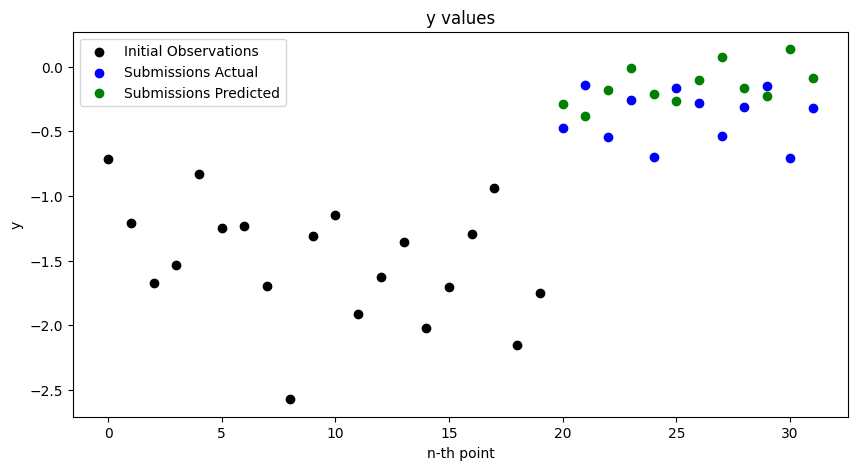

In [12]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

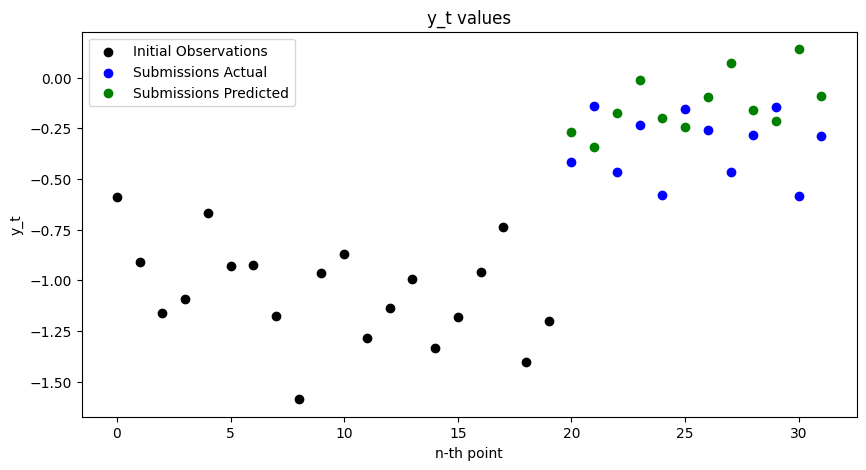

In [13]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [14]:
x_grid = grid_helper.hypercube_grid([10, 10, 10, 10, 10], x_col_names)

#print(x_grid[0:5])

len(x_grid): 161051


### Maximise UCB and EI acquisition functions

In [15]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))
    
df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.       0.       0.999999 0.       0.      ]) = 6.661263114417304e-23, distance: 0.833761847908622, y_t_best: [-0.64005369], y_best: [-0.81447906]
EI trans space (xi=1)...
Acq Fn([0.       0.       0.999999 0.999999 0.      ]) = 1.0830979594331682e-08, distance: 0.5168503139720435, y_t_best: [-0.2826428], y_best: [-0.32881062]
EI trans space (xi=0.5)...
Acq Fn([0.       0.       0.999999 0.999999 0.      ]) = 0.00015912695803907894, distance: 0.5168503139720435, y_t_best: [-0.2826428], y_best: [-0.32881062]
EI trans space (xi=0.1)...
Acq Fn([0.35777079 0.         0.60409335 0.82701665 0.105556  ]) = 0.02044042953586548, distance: 0.31050971034271857, y_t_best: [-0.10309664], y_best: [-0.11108005]
EI trans space (xi=0.05)...
Acq Fn([0.36761069 0.02644823 0.60403009 0.82482389 0.110612  ]) = 0.039178960977884106, distance: 0.31116378911000053, y_t_best: [-0.09436375], y_best: [-0.10105606]
EI trans space (xi=0.01)...
Acq Fn([0.37910668 0.12837669 0.60434

### Display the acquisition function results

In [16]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

x_t = x_transform.transform(df[x_col_names].iloc[0].values.reshape(-1,x_dim))
y_t_mean, y_t_std = best_model.predict(np.atleast_2d(x_t), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: -0.14607787463425093
Actual y_t: -0.13950087700785344
x: [0.415568 0.341049 0.608121 0.821555 0.200255]


<br>**Model's [Linear + RBF, x:scaled, y:power] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [-0.13950094], y_t_std: [9.99997288e-05]
y_mean: [-0.14607795]



<br>**FUNCTION 6 SUBMISSION WEEK 13:**<br>

                     acq_fn               ['x1', 'x2', 'x3', 'x4', 'x5']  distance  y_t_mean    y_mean  y_mean rank
      EI trans space (xi=2) 0.000000-0.000000-0.999999-0.000000-0.000000  0.833762 -0.640054 -0.814479           25
      EI trans space (xi=1) 0.000000-0.000000-0.999999-0.999999-0.000000  0.516850 -0.282643 -0.328811           20
    EI trans space (xi=0.5) 0.000000-0.000000-0.999999-0.999999-0.000000  0.516850 -0.282643 -0.328811           20
    EI trans space (xi=0.1) 0.357771-0.000000-0.604093-0.827017-0.105556  0.310510 -0.103097 -0.111080           18
   EI trans space (xi=0.05) 0.367611-0.026448-0.604030-0.824824-0.110612  0.311164 -0.094364 -0.101056           15
   EI trans space (xi=0.01) 0.379107-0.128377-0.604349-0.820227-0.117120  0.227893 -0.077600 -0.081668           12
  EI trans space (xi=0.005) 0.380595-0.139897-0.604439-0.819767-0.117835  0.218436 -0.076323 -0.080161           11
  EI trans space (xi=0.001) 0.381764-0.148736-0.604514-0.819420-0.118383

## Manually calculating the prediction at an x point (Helper method)